In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [110]:
df = pd.read_csv('insurance.csv')
df.head()
# df.isnull().sum()
# df.info()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Feature Engineering

#### Gender Encoding

In [111]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [112]:
def genderCategory(gender_data):
    if gender_data=='female':
        return 0
    else:
        return 1

In [113]:
df['gender'] = df['gender'].apply(genderCategory)

#### Smoker Encoding

In [114]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [115]:
def smokerEncoding(smoker_data):
    if smoker_data =='yes':
        return 1
    else:
        return 0
    
df['smoker'] = df['smoker'].apply(smokerEncoding)

#### Region Encoding

In [116]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [117]:
def regionEncoding(region_data):
    if region_data =='southwest':
        return 1
    elif region_data == 'southeast':
        return 2
    elif region_data == 'northwest':
        return 3
    else:
        return 4
    
df['region'] = df['region'].apply(regionEncoding)

In [118]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,3,10600.54830
1334,18,0,31.920,0,0,4,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,1,2007.94500


## Visualization

In [119]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,3,10600.54830
1334,18,0,31.920,0,0,4,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,1,2007.94500


<Axes: ylabel='region'>

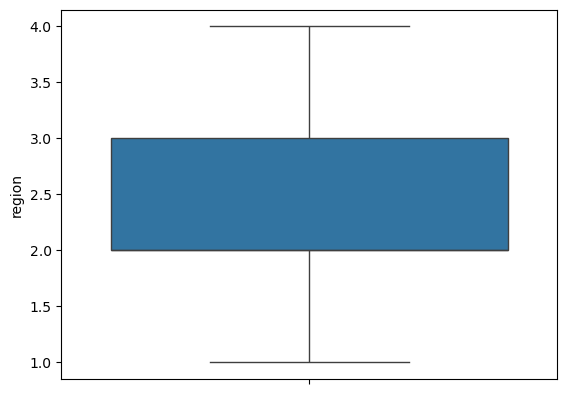

In [120]:
sns.boxplot(df['region'])

<Axes: >

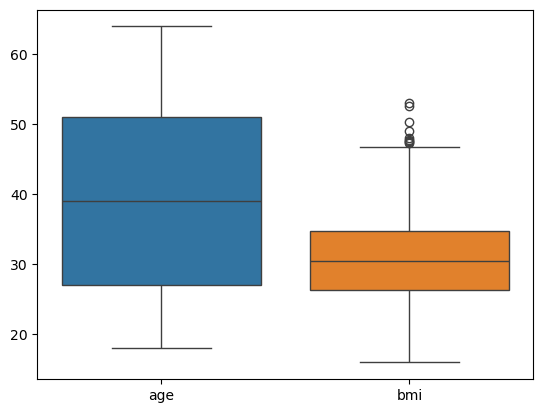

In [121]:
sns.boxplot(df[['age','bmi']])

<Axes: ylabel='charges'>

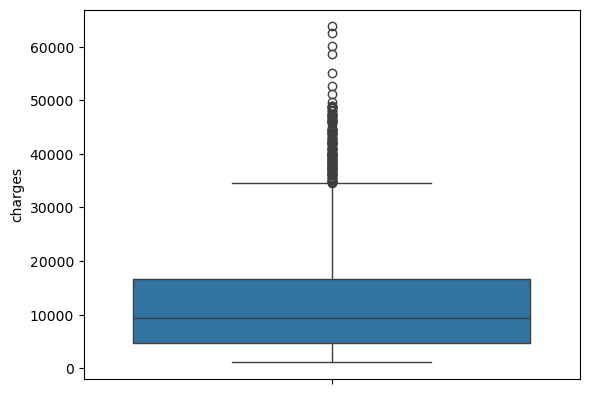

In [122]:
sns.boxplot(df['charges'])

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


## Train Test

In [124]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [125]:
feature=['age', 'gender', 'bmi', 'children', 'smoker', 'region']
target=['charges']
X=df[feature]
Y=df[target]

In [126]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

## Linear Regression

In [127]:
linear_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('linear_reg',LinearRegression())
])
linear_reg.fit(X_train, Y_train)
linear_reg_pred = linear_reg.predict(X_test)

Text(0, 0.5, 'Predicted charges')

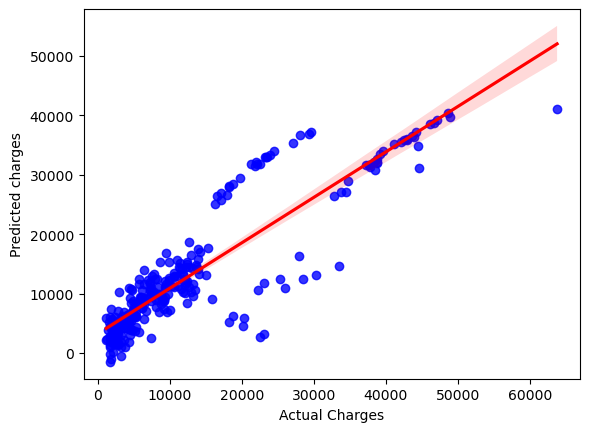

In [128]:
sns.regplot(x=Y_test, y=linear_reg_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual Charges')
plt.ylabel('Predicted charges')

In [129]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_score = cross_val_score(
    linear_reg,
    X,
    Y.values.ravel(),
    cv=kfold,
    scoring='r2'
)

print(f'Cross validation score: {cv_score}')
print(f'Average cross validation score: {cv_score.mean()}')

Cross validation score: [0.78334631 0.74026709 0.79566892 0.63244564 0.75199803]
Average cross validation score: 0.7407451971654287


In [130]:
def adjustR2(r2, n, p):
    return 1-((1-r2)*(n-1))/(n-p-1)

n_sample = X_test.shape[0]
p = X_train.shape[1]

In [131]:
mae = mean_absolute_error(Y_test, linear_reg_pred)
mse = mean_squared_error(Y_test, linear_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, linear_reg_pred)
linreg_adjust_r2 = adjustR2(r2, n_sample, p)

print(f'Mean Absolute Error(MAE): {mae}')
print(f'Mean Squared Error(MSE): {mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function): {rmse}')
print(f'R2 Score (Residual Score / Cost Function): {r2}')
print(f'Adjusted R2 Score: {linreg_adjust_r2}')

Mean Absolute Error(MAE): 4186.508898366437
Mean Squared Error(MSE): 33635210.431178436
Root Mean Squared Error(RMSE/Loss Function): 5799.587091438359
R2 Score (Residual Score / Cost Function): 0.7833463107364537
Adjusted R2 Score: 0.7783657661556824


## Polynomial Regression

In [132]:
poly_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('poly_reg', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_reg',LinearRegression())
])
poly_reg.fit(X_train, Y_train)
poly_reg_pred = poly_reg.predict(X_test)

poly_mae = mean_absolute_error(Y_test, poly_reg_pred)
poly_mse = mean_squared_error(Y_test, poly_reg_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(Y_test, poly_reg_pred)
poly_reg_adjust_r2 = adjustR2(poly_r2, n_sample, p)

print(f'Mean Absolute Error(MAE): {poly_mae}')
print(f'Mean Squared Error(MSE): {poly_mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function): {poly_rmse}')
print(f'R2 Score (Residual Score / Cost Function): {poly_r2}')
print(f'Adjusted R2 Score: {poly_reg_adjust_r2}')

Mean Absolute Error(MAE): 2725.3897591380596
Mean Squared Error(MSE): 20526533.376460765
Root Mean Squared Error(RMSE/Loss Function): 4530.621742814198
R2 Score (Residual Score / Cost Function): 0.8677829237042851
Adjusted R2 Score: 0.8647434506859928


## Ridge Regression

In [133]:
ridge_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('ridge_reg', Ridge(alpha = 1.0)),
])
ridge_reg.fit(X_train, Y_train)
ridge_reg_pred = ridge_reg.predict(X_test)

ridge_r2 = r2_score(Y_test, ridge_reg_pred)
print(f'R2 Score (Residual Score / Cost Function): {ridge_r2}')


R2 Score (Residual Score / Cost Function): 0.7833037457661384


## Lasso Regression

In [134]:
lasso_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('lasso_reg', Lasso(alpha = 0.1)),
])
lasso_reg.fit(X_train, Y_train)
lasso_reg_pred = lasso_reg.predict(X_test)

lasso_r2 = r2_score(Y_test, lasso_reg_pred)
print(f'R2 Score (Residual Score / Cost Function): {lasso_r2}')


R2 Score (Residual Score / Cost Function): 0.7833446180192526


## ElasticNet Regression

In [135]:
en_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('en_reg', ElasticNet(alpha = 0.1)),
])
en_reg.fit(X_train, Y_train)
en_reg_pred = en_reg.predict(X_test)

en_r2 = r2_score(Y_test, en_reg_pred)
print(f'R2 Score (Residual Score / Cost Function): {en_r2}')


R2 Score (Residual Score / Cost Function): 0.7794607447977664


In [136]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_poly',PolynomialFeatures(degree=2, include_bias=False)),
    ('rf_regressor', RandomForestRegressor())
])
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(Y_test,rf_pred)
rf_mse = mean_squared_error(Y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
r2 = r2_score(Y_test,rf_pred)

print(f'Mean Absolute Error(MAE):{rf_mae}')
print(f'Mean Squared Error(MSE):{rf_mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function):{rf_rmse}')
print(f'R2 Score(Residual Score/ Cost Function):{r2}')

c:\Users\Acer\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Absolute Error(MAE):2635.7885157497517
Mean Squared Error(MSE):21787143.843229927
Root Mean Squared Error(RMSE/Loss Function):4667.670065806915
R2 Score(Residual Score/ Cost Function):0.8596629831762302


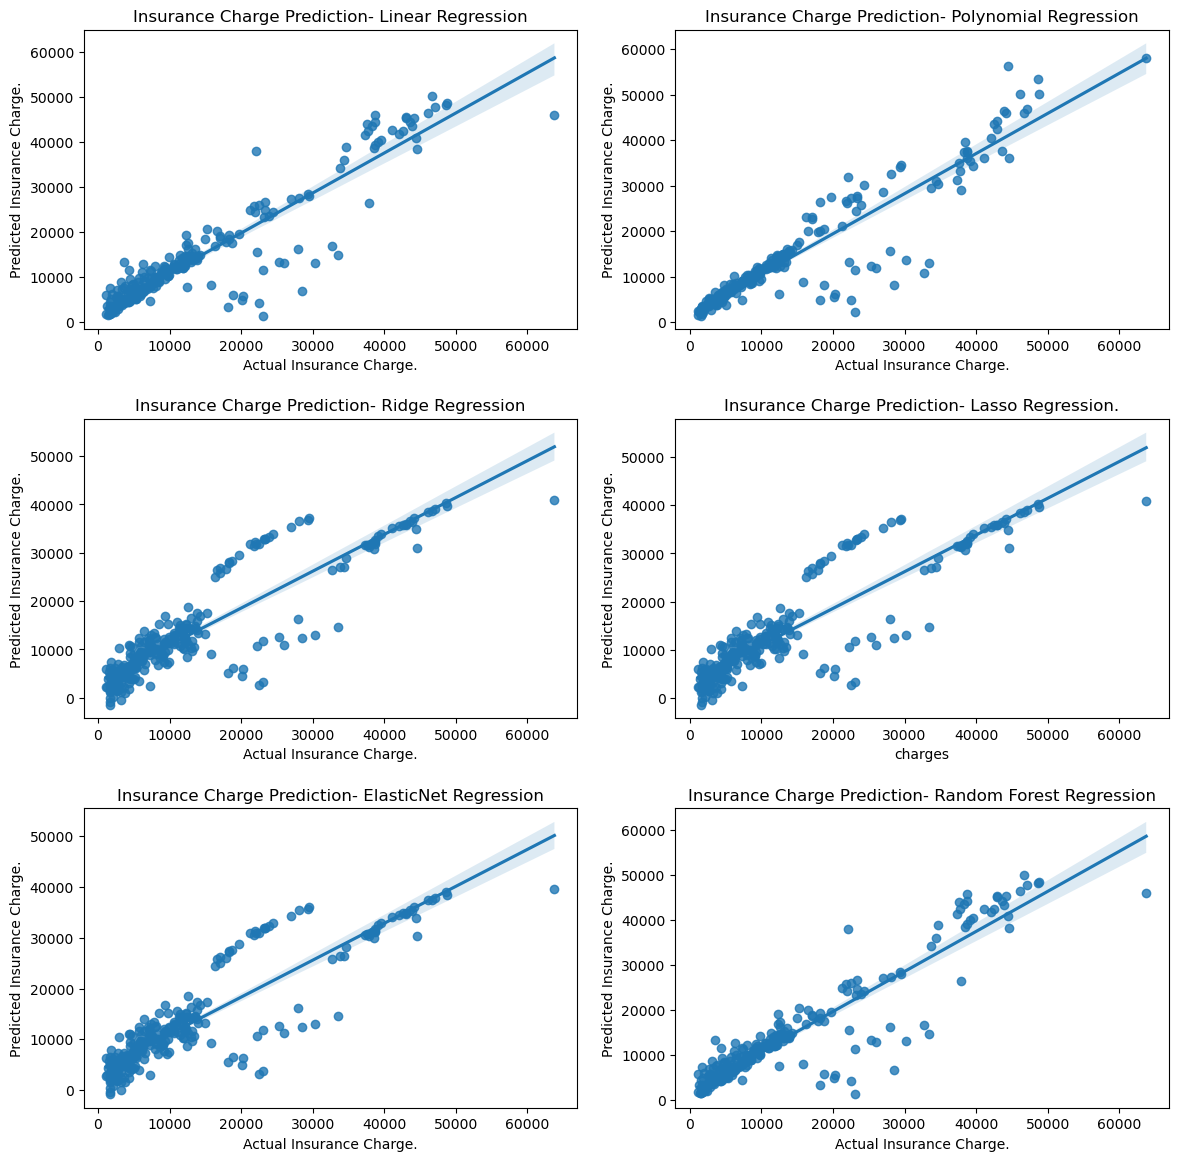

In [137]:
fig, axes = plt.subplots(3,2,figsize =(14,14))
plt.subplots_adjust(hspace=0.3)

sns.regplot(x=Y_test, y=rf_pred, ax=axes[0,0])
axes[0,0].set_title('Insurance Charge Prediction- Linear Regression')
axes[0,0].set_xlabel('Actual Insurance Charge.')
axes[0,0].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=poly_reg_pred, ax=axes[0,1])
axes[0,1].set_title(('Insurance Charge Prediction- Polynomial Regression'))
axes[0,1].set_xlabel('Actual Insurance Charge.')
axes[0,1].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=ridge_reg_pred, ax=axes[1,0])
axes[1,0].set_title(('Insurance Charge Prediction- Ridge Regression'))
axes[1,0].set_xlabel('Actual Insurance Charge.')
axes[1,0].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=lasso_reg_pred, ax=axes[1,1])
axes[1,1].set_title('Insurance Charge Prediction- Lasso Regression.')
axes[1,1].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=en_reg_pred, ax=axes[2,0])
axes[2,0].set_title(('Insurance Charge Prediction- ElasticNet Regression'))
axes[2,0].set_xlabel('Actual Insurance Charge.')
axes[2,0].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=rf_pred, ax=axes[2,1])
axes[2,1].set_title(('Insurance Charge Prediction- Random Forest Regression'))
axes[2,1].set_xlabel('Actual Insurance Charge.')
axes[2,1].set_ylabel('Predicted Insurance Charge.')


plt.show()